8x8 lidar sensor: ST VL53L7CX

In [1]:
import sympy
import pickle
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [2]:
with open("parameters.pickle", "rb") as file:
    M1, d1, M2, d2, T, R, Q, ROI1, ROI2, R1, R2, Pn1, Pn2 = pickle.load(file)

In [3]:
q00, q01, q02, q03, \
q10, q11, q12, q13, \
q20, q21, q22, q23, \
q30, q31, q32, q33 = sympy.symbols(
    "q_00 q_01 q_02 q_03 \
q_10 q_11 q_12 q_13 \
q_20 q_21 q_22 q_23 \
q_30 q_31 q_32 q_33"
)
Qs = sympy.Matrix([
    [q00, q01, q02, q03],
    [q10, q11, q12, q13],
    [q20, q21, q22, q23],
    [q30, q31, q32, q33]
])
Qs

Matrix([
[q_00, q_01, q_02, q_03],
[q_10, q_11, q_12, q_13],
[q_20, q_21, q_22, q_23],
[q_30, q_31, q_32, q_33]])

In [4]:
u, v, d = sympy.symbols("u v d")
P = sympy.Matrix([
    [u],
    [v],
    [d],
    [1]
])
P

Matrix([
[u],
[v],
[d],
[1]])

In [5]:
r = Qs @ P
r /= r[3]
r

Matrix([
[(d*q_02 + q_00*u + q_01*v + q_03)/(d*q_32 + q_30*u + q_31*v + q_33)],
[(d*q_12 + q_10*u + q_11*v + q_13)/(d*q_32 + q_30*u + q_31*v + q_33)],
[(d*q_22 + q_20*u + q_21*v + q_23)/(d*q_32 + q_30*u + q_31*v + q_33)],
[                                                                  1]])

In [6]:
D = sympy.sqrt(
    (r[0] ** 2) +
    (r[1] ** 2) +
    (r[2] ** 2)
)
D

sqrt((d*q_02 + q_00*u + q_01*v + q_03)**2/(d*q_32 + q_30*u + q_31*v + q_33)**2 + (d*q_12 + q_10*u + q_11*v + q_13)**2/(d*q_32 + q_30*u + q_31*v + q_33)**2 + (d*q_22 + q_20*u + q_21*v + q_23)**2/(d*q_32 + q_30*u + q_31*v + q_33)**2)

In [7]:
D = D.subs({
    q00: float(Q[0,0]),
    q01: float(Q[0,1]),
    q02: float(Q[0,2]),
    q03: float(Q[0,3]),
    q10: float(Q[1,0]),
    q11: float(Q[1,1]),
    q12: float(Q[1,2]),
    q13: float(Q[1,3]),
    q20: float(Q[2,0]),
    q21: float(Q[2,1]),
    q22: float(Q[2,2]),
    q23: float(Q[2,3]),
    q30: float(Q[3,0]),
    q31: float(Q[3,1]),
    q32: float(Q[3,2]),
    q33: float(Q[3,3])
})
dD = D.diff(d)
dD

25.5527583394866*(-0.361665557189062*(0.00267441276218376*u - 1)**2/d**3 - 0.238853928130016*(0.00329090857757198*v - 1)**2/d**3 - 1/d**3)/sqrt(0.361665557189062*(0.00267441276218376*u - 1)**2/d**2 + 0.238853928130016*(0.00329090857757198*v - 1)**2/d**2 + d**(-2))

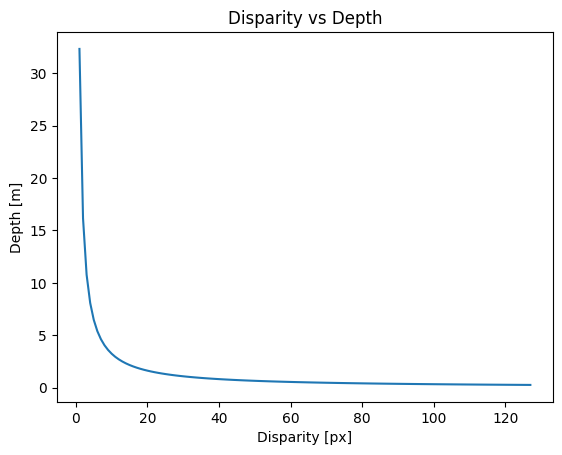

In [8]:
disp = range(1, 128)

plt.plot(disp, [D.evalf(subs={d: _d, u: 0, v: 0}) for _d in disp])
plt.xlabel("Disparity [px]")
plt.ylabel("Depth [m]")
plt.title("Disparity vs Depth")
plt.show()

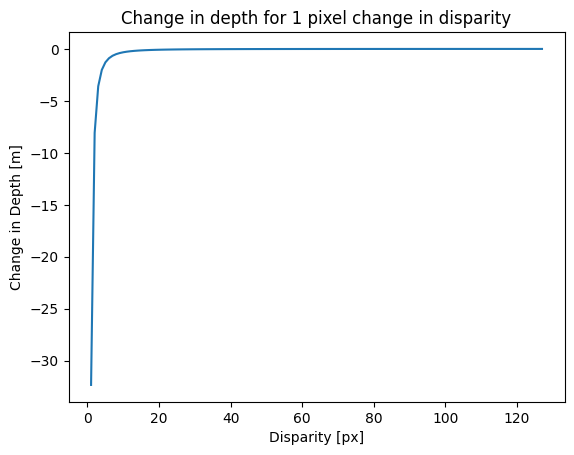

In [9]:
plt.plot(disp, [dD.evalf(subs={d: _d, u: 0, v: 0}) for _d in disp])
plt.xlabel("Disparity [px]")
plt.ylabel("Change in Depth [m]")
plt.title("Change in depth for 1 pixel change in disparity")
plt.show()

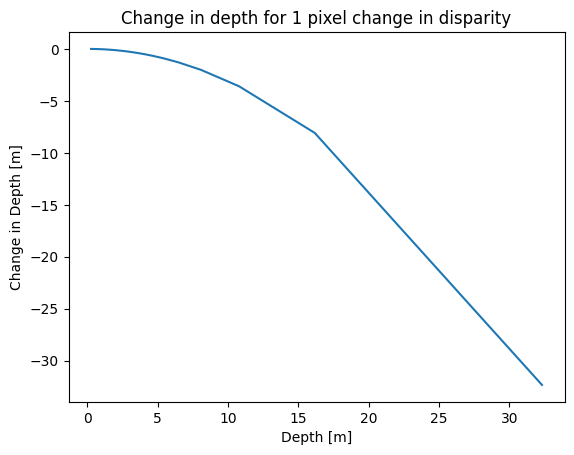

In [10]:
plt.plot([D.evalf(subs={d: _d, u: 0, v: 0}) for _d in disp], [dD.evalf(subs={d: _d, u: 0, v: 0}) for _d in disp])
plt.xlabel("Depth [m]")
plt.ylabel("Change in Depth [m]")
plt.title("Change in depth for 1 pixel change in disparity")
plt.show()

[-3.09336899e-02 -1.60234649e-09  3.26035585e-09]
[[ 1.80805316e-23 -9.10062736e-23 -1.05090596e-22]
 [-9.10062736e-23  4.54672305e-20 -1.50370820e-21]
 [-1.05090596e-22 -1.50370820e-21  1.19628606e-20]]


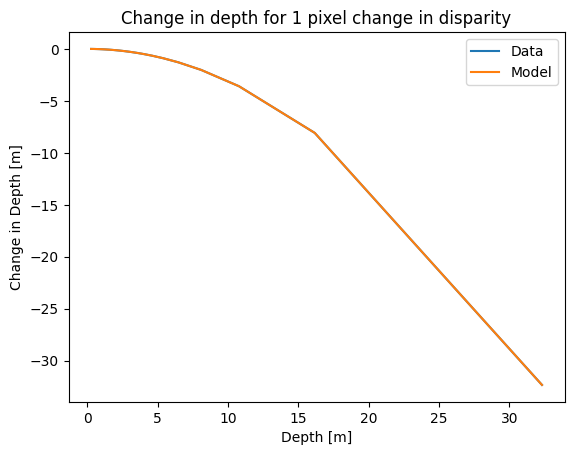

In [11]:
def f(x, a, b, c):
    return (a * x**2) + (b*x) + c

x = [float(D.evalf(subs={d: _d, u: 0, v: 0})) for _d in disp]
y = [float(dD.evalf(subs={d: _d, u: 0, v: 0})) for _d in disp]
param, cov = curve_fit(f, x, y)
print(param)
print(cov)

plt.plot(x, y, label="Data")
plt.plot(x, [f(_x, *param) for _x in x], label="Model")
plt.xlabel("Depth [m]")
plt.ylabel("Change in Depth [m]")
plt.title("Change in depth for 1 pixel change in disparity")
plt.legend()
plt.show()